In [1]:
import matplotlib.pyplot as plt
import numpy as np
from amocatlas import read

from correlation_trends import (
    analysis,
    correlation,
    seasonal,
    trends,
)

In [2]:
figpath = "../figures/"

In [3]:
## Read the datasets

# 26N transports: MOC, TRANS_FC, TRANS_EKMAN, TRANS_UMO
transports = read.rapid()

# 26N boundary hydrography for Part 1 (TEMP_/PSAL_ WEST & EAST on PRESSURE)

MOC = transports.MOC
TRANS_FC = transports.TRANS_FC
TRANS_EKMAN = transports.TRANS_EKMAN
TRANS_UMO = transports.TRANS_UMO

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series



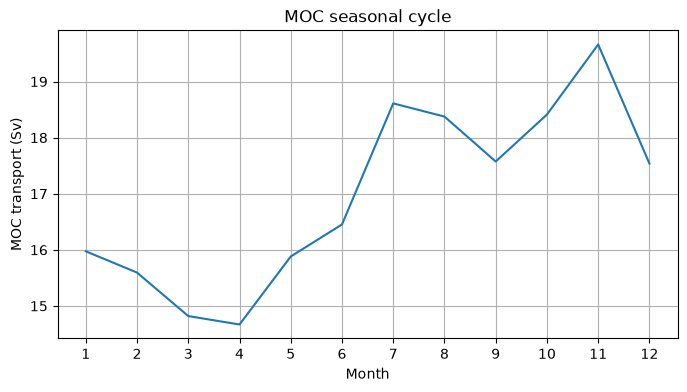

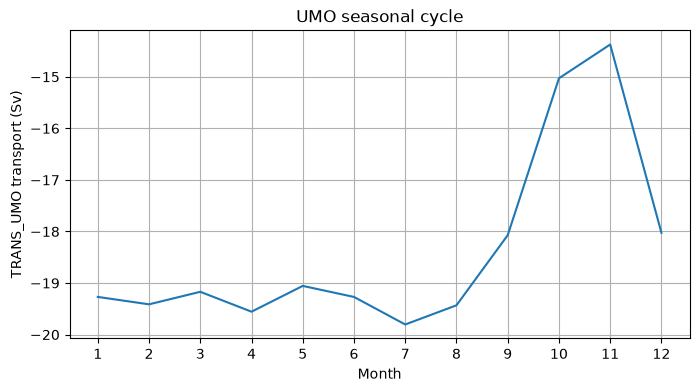

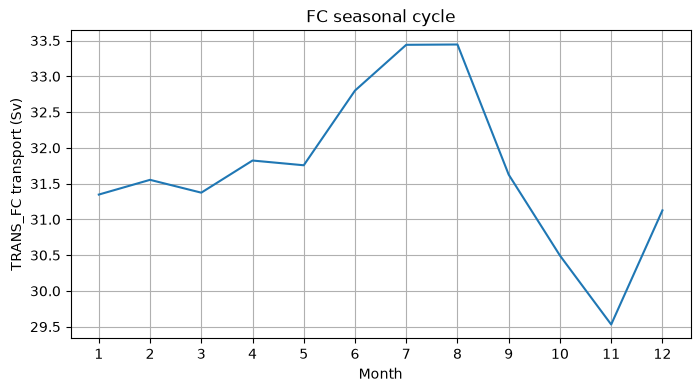

In [4]:
seasonal.plot_seasonal_cycle(MOC)
plt.title("MOC seasonal cycle")
plt.savefig(figpath + "MOC_seasonal_cycle.png")
plt.show()
seasonal.plot_seasonal_cycle(TRANS_UMO)
plt.title("UMO seasonal cycle")
plt.savefig(figpath + "UMO_seasonal_cycle.png")
plt.show()
seasonal.plot_seasonal_cycle(TRANS_FC)
plt.title("FC seasonal cycle")
plt.savefig(figpath + "FC_seasonal_cycle.png")
plt.show()

In [5]:
# deseasonalize the timeseries
MOC_deseasonalized = seasonal.remove_seasonal_cycle(MOC)
UMO_deseasonalized = seasonal.remove_seasonal_cycle(TRANS_UMO)

# to plot it, it makes sense to transform the seasonal and deseasonalized datasets to monthly data
monthly_MOC_deseasonalized = MOC_deseasonalized.resample(TIME="ME").mean()
monthly_MOC = MOC.resample(TIME="ME").mean()

monthly_UMO_deseasonalized = UMO_deseasonalized.resample(TIME="ME").mean()
monthly_UMO = TRANS_UMO.resample(TIME="ME").mean()

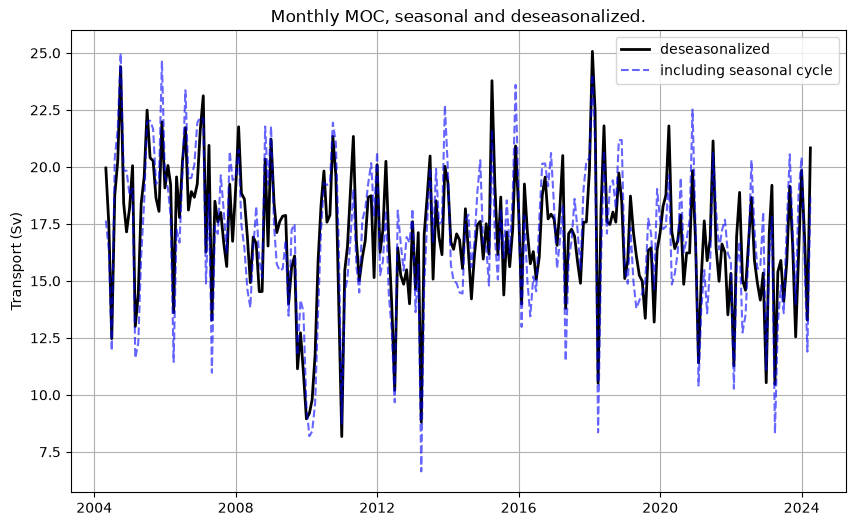

In [16]:
plt.figure(figsize=[10, 6])
plt.title("Monthly MOC, seasonal and deseasonalized.")
plt.plot(monthly_MOC["TIME"], monthly_MOC_deseasonalized, color="k", lw=2, label ="deseasonalized")
plt.plot(monthly_MOC["TIME"], monthly_MOC, color="blue", alpha=0.6, ls="--", label ="including seasonal cycle")
plt.grid()
plt.ylabel("Transport (Sv)")
plt.legend()
plt.savefig(figpath + "MOC_seasonal_cycle_comparison.png")

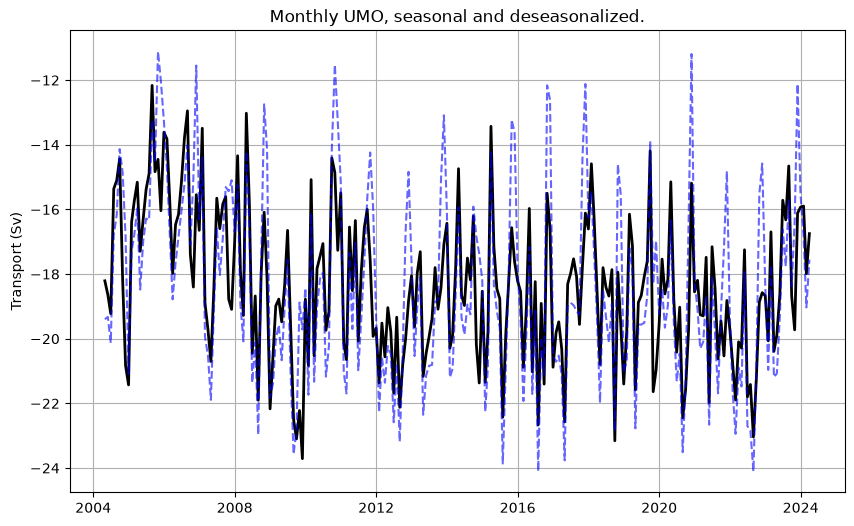

In [17]:
plt.figure(figsize=[10, 6])
plt.title("Monthly UMO, seasonal and deseasonalized.")
plt.plot(monthly_MOC["TIME"], monthly_UMO_deseasonalized, color="k", lw=2, label ="deseasonalized")
plt.plot(monthly_MOC["TIME"], monthly_UMO, color="blue", alpha=0.6, ls="--", label ="including seasonal cycle")
plt.grid()
plt.ylabel("Transport (Sv)")
plt.savefig(figpath + "UMO_seasonal_cycle_comparison.png")

In [8]:
# detrend the original, not yet deseasonalized time series
MOC_seasonal_detrended = analysis.detrending(MOC, MOC["TIME"].values)
UMO_seasonal_detrended = analysis.detrending(TRANS_UMO, TRANS_UMO["TIME"].values)

# calculate the auto-correlation of the seasonal detrendend time series
ac_MOC_seasonal = correlation.autocorr(MOC_seasonal_detrended, biased=True)
ac_UMO_seasonal = correlation.autocorr(UMO_seasonal_detrended, biased=True)

# calculate the decorrelation timescale (using the integral time scale definition with a cutoff at the first zero crossing)
MOC_decorrelation_timescale = correlation.integral_timescale(
    MOC_seasonal_detrended, dt=0.5
)
UMO_decorrelation_timescale = correlation.integral_timescale(
    UMO_seasonal_detrended, dt=0.5
)
print(MOC_decorrelation_timescale)
print(UMO_decorrelation_timescale)

18.511922864244802
22.51603193162272


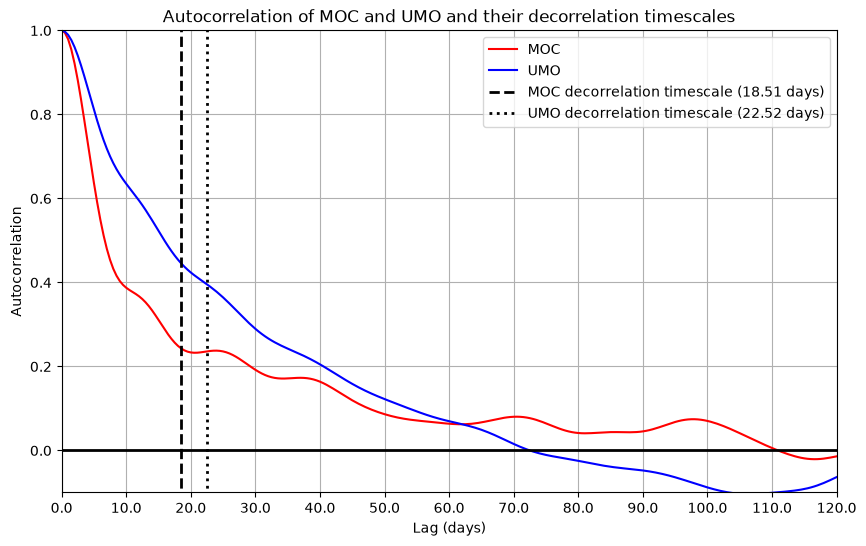

In [18]:
plt.figure(figsize=[10, 6])
plt.title("Autocorrelation of MOC and UMO and their decorrelation timescales")
plt.plot(np.arange(len(ac_MOC_seasonal)), ac_MOC_seasonal, color="red", label="MOC")
plt.plot(np.arange(len(ac_UMO_seasonal)), ac_UMO_seasonal, color="blue", label="UMO")
plt.vlines(
    MOC_decorrelation_timescale * 2,
    -1,
    2,
    lw=2,
    ls="--",
    color="k",
    label=f"MOC decorrelation timescale ({MOC_decorrelation_timescale:.2f} days)",
)
plt.vlines(
    UMO_decorrelation_timescale * 2,
    -1,
    2,
    lw=2,
    ls=":",
    color="k",
    label=f"UMO decorrelation timescale ({UMO_decorrelation_timescale:.2f} days)",
)
plt.hlines(0, -1, 1000, ls="-", lw=2, color="k")
plt.xticks(
    np.arange(0, len(ac_MOC_seasonal), 20),
    np.arange(0, len(ac_MOC_seasonal) / 2, 20 / 2),
)
plt.xlim(0, 2 * 120)
plt.ylim(-0.1, 1)
plt.ylabel("Autocorrelation")
plt.xlabel("Lag (days)")
plt.legend()
plt.grid()
plt.savefig(figpath + "MOC_UMO_autocorrelation.png")
plt.show()

In [10]:
MOC_N_eff = correlation.effective_dof(MOC_seasonal_detrended, 0.5)
UMO_N_eff = correlation.effective_dof(UMO_seasonal_detrended, 0.5)
print(f"Number of effective samples in the RAPID MOC timeseries {MOC_N_eff}")
print(f"Number of effective samples in the RAPID UMO timeseries {UMO_N_eff}")

Number of effective samples in the RAPID MOC timeseries 196
Number of effective samples in the RAPID UMO timeseries 161


In [11]:
predictor = np.arange(len(MOC))
MOC_trend_result = trends.trend_with_significance(predictor, MOC, dt=0.5)
UMO_trend_result = trends.trend_with_significance(predictor, TRANS_UMO, dt=0.5)
MOC_ci_lower, MOC_ci_upper = trends.confband(predictor, MOC, dt=0.5)
UMO_ci_lower, UMO_ci_upper = trends.confband(predictor, TRANS_UMO, dt=0.5)

no xarray type, possibly already detrended
no xarray type, possibly already detrended
no xarray type, possibly already detrended
no xarray type, possibly already detrended


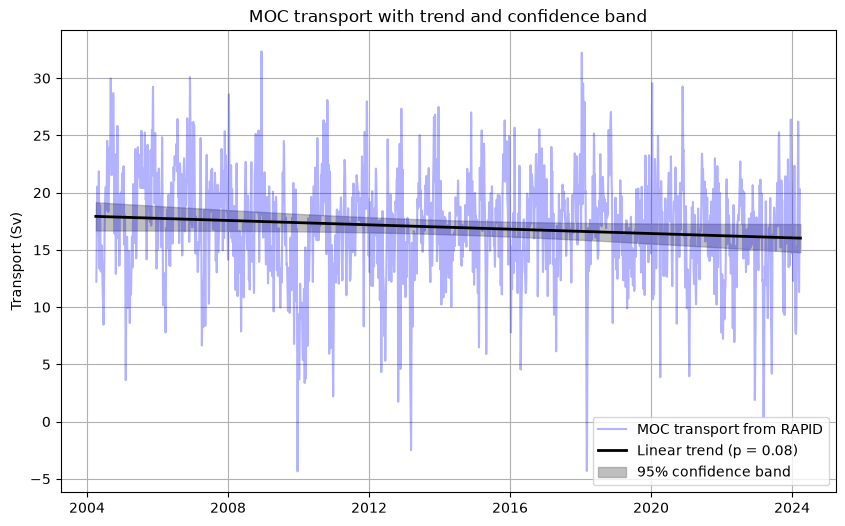

In [22]:
plt.figure(figsize=[10, 6])
plt.title("MOC transport with trend and confidence band")
plt.plot(MOC["TIME"], MOC, color="blue", alpha=0.3, label="MOC transport from RAPID")
plt.plot(
    MOC["TIME"],
    MOC_trend_result.slope * np.arange(MOC.size) + MOC_trend_result.intercept,
    color="k",
    lw=2,
    label=f"Linear trend (p = {MOC_trend_result.p_eff:.2f})",
)
plt.fill_between(
    MOC["TIME"],
    MOC_ci_lower,
    MOC_ci_upper,
    alpha=0.5,
    label="95% confidence band",
    color="grey",
)
plt.grid()
plt.ylabel("Transport (Sv)")
plt.legend()
plt.savefig(figpath + "MOC_trend.png")

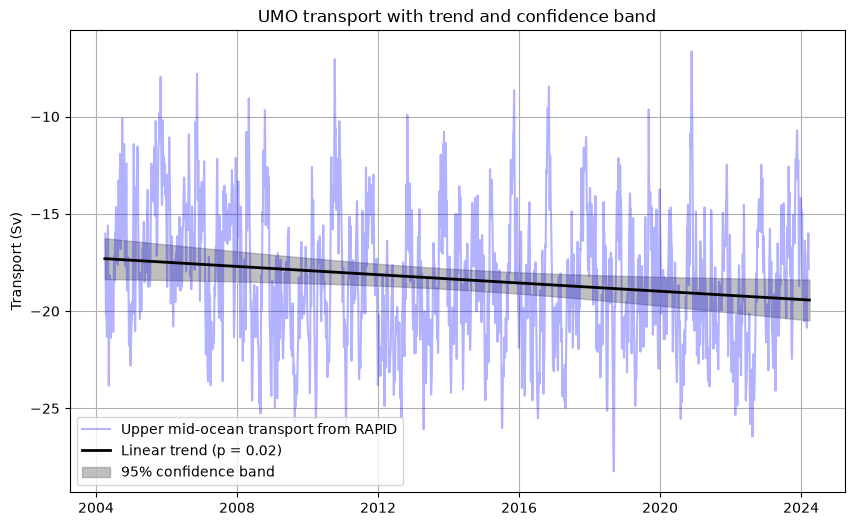

In [21]:
plt.figure(figsize=[10, 6])
plt.title("UMO transport with trend and confidence band")
plt.plot(
    TRANS_UMO["TIME"],
    TRANS_UMO,
    color="blue",
    alpha=0.3,
    label="Upper mid-ocean transport from RAPID",
)
plt.plot(
    TRANS_UMO["TIME"],
    UMO_trend_result.slope * np.arange(TRANS_UMO.size) + UMO_trend_result.intercept,
    color="k",
    lw=2,
    label=f"Linear trend (p = {UMO_trend_result.p_eff:.2f})",
)

plt.fill_between(
    TRANS_UMO["TIME"],
    UMO_ci_lower,
    UMO_ci_upper,
    alpha=0.5,
    label="95% confidence band",
    color="grey",
)
plt.legend()
plt.grid()
plt.ylabel("Transport (Sv)")
plt.savefig(figpath + "UMO_trend.png")

In [14]:
print(
    f"There is a {(100 * MOC_trend_result.p_eff):.2f} % chance that the measured decline of the MOC measured by the RAPID array is due to chaotic random chance."
)
print("The MOC decline is not siginficant at 95%.")
print(
    f"There is a {(100 * UMO_trend_result.p_eff):.2f} % chance that the measured decline of the UMO measured by the RAPID array is due to chaotic random chance."
)
print("The UMO decline is siginficant at 95%.")

There is a 8.09 % chance that the measured decline of the MOC measured by the RAPID array is due to chaotic random chance.
The MOC decline is not siginficant at 95%.
There is a 2.20 % chance that the measured decline of the UMO measured by the RAPID array is due to chaotic random chance.
The UMO decline is siginficant at 95%.
